In [ ]:
import os
import json
import random
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from gap.classifiers import ScalableResNetLite
from gap.adv import AdversarialAttacker
from gap.spectral import SpectralAnalyzer
from gap.purify import purify_ddpm

from gap.purification.train_scriptv2 import GaussianDiffusion, HyperConfig, UNetLite

In [2]:
# Set up environment, choose model to load
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

RUN_DIR = "../saved_models"

clf_metadata_path = os.path.join(RUN_DIR, "cifar10_metadata.json")
clf_weights_path = os.path.join(RUN_DIR, "cifar10_classifier.pth")

dm_metadata_path = os.path.join(RUN_DIR, "cifar10_diffusion/best_model.pt")

with open(clf_metadata_path, "r") as f:
    clf_best_model = json.load(f)

clf_best_config = clf_best_model["model_config"]
print(f"Loaded classifier config: {clf_best_config}")

Using device: mps
Loaded classifier config: {'lr': 0.0001838809343739058, 'channels': 96, 'depth': 4, 'optimizer': 'adam', 'weight_decay': 0.0005}


In [3]:
# Instantiate the model using the weights and metadata loaded
clf_trained_model = ScalableResNetLite(
    num_classes=10, channels=clf_best_config["channels"], depth=clf_best_config["depth"]
).to(device)

clf_trained_model.load_state_dict(
    torch.load(clf_weights_path, map_location=device, weights_only=True)
)
clf_trained_model.eval()
print("Classification model loaded successfully!")

Classification model loaded successfully!


In [4]:
def load_diffusion_model(checkpoint_path, in_channels=3, device="cpu"):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    hcfg_dict = checkpoint["hcfg"]
    hcfg = HyperConfig(**hcfg_dict)
    print(f"Loaded Hyperparameters: {hcfg}")
    
    unet = UNetLite(
        in_channels=in_channels,
        base_channels=hcfg.base_channels,
        channel_mults=hcfg.channel_mults,
        num_res_blocks=hcfg.num_res_blocks,
        dropout=hcfg.dropout
    ).to(device)
    
    unet.load_state_dict(checkpoint["model"])
    unet.eval()
    
    diffusion = GaussianDiffusion(unet, num_timesteps=hcfg.num_timesteps).to(device)
    diffusion.eval()
    
    return diffusion, hcfg

def load_dae_model(checkpoint_path, in_channels=3, device="cpu"):
    return

In [5]:
dm, dm_config = load_diffusion_model(RUN_DIR + "/cifar10_diffusion/best_model.pt")
#dae, dae_config = load_dae_model(RUN_DIR + "/cifar10_dae/best_model.pt")

Loaded Hyperparameters: HyperConfig(base_channels=32, channel_mults=(1, 2, 4), num_res_blocks=2, dropout=0.1, lr=0.0001, batch_size=32, num_timesteps=400)


In [6]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

test_data = datasets.CIFAR10(
    root="../datasets", train=False, download=True, transform=transform
)

# There are 10000 test samples to choose from
test_subset = Subset(test_data, range(10000))
eval_loader = DataLoader(test_subset, batch_size=128, shuffle=False)
print("Data loaded successfully! Ready for adversarial generation.")

Data loaded successfully! Ready for adversarial generation.


/Users/austinb.dev.bc/Projects/gap/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Next steps: **Prepare the data for purification**
- Perform inference on the test data loaded with the loaded classification model.
- Identify all of the samples that were classified correctly and take that subset of samples.
- Generate adversarial data examples for all of those correctly classified samples from the test data. Use both PGD and FGSM.

In [7]:
attacker = AdversarialAttacker(clf_trained_model, device)

original_loader = attacker.get_correct_subset_loader(eval_loader)

Filtering for correctly classified samples...
Filtering complete. Accuracy 86.19.


In [8]:
fgsm_loader = attacker.generate_adversarial_dataset(
    original_loader, attack_type="fgsm", epsilon=1 / 255
)
pgd_loader = attacker.generate_adversarial_dataset(
    original_loader, attack_type="pgd", epsilon=1 / 255
)

Generating FGSM adversarial examples...
Generating PGD adversarial examples...


In [9]:
os.makedirs("../datasets/adversarial", exist_ok=True)

fgsm_images, fgsm_labels = fgsm_loader.dataset.tensors
pgd_images, pgd_labels = pgd_loader.dataset.tensors

torch.save(
    {"images": fgsm_images, "labels": fgsm_labels},
    "../datasets/adversarial/cifar10_fgsm_eps0.03.pt",
)

torch.save(
    {"images": pgd_images, "labels": pgd_labels},
    "../datasets/adversarial/cifar10_pgd_eps0.03.pt",
)

print("Adversarial tensors saved successfully to ../datasets/adversarial/")

Adversarial tensors saved successfully to ../datasets/adversarial/


We now can load the adversarial examples and their original labels directly from storage.

In [8]:
fgsm_data_dict = torch.load(
    "../datasets/adversarial/cifar10_fgsm_eps0.03.pt", weights_only=True
)

fgsm_dataset = TensorDataset(fgsm_data_dict["images"], fgsm_data_dict["labels"])
fgsm_loader = DataLoader(fgsm_dataset, batch_size=128, shuffle=False)

pgd_data_dict = torch.load(
    "../datasets/adversarial/cifar10_pgd_eps0.03.pt", weights_only=True
)

pgd_dataset = TensorDataset(pgd_data_dict["images"], pgd_data_dict["labels"])
pgd_loader = DataLoader(pgd_dataset, batch_size=128, shuffle=False)

In [19]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def get_predictions_and_probs(model, dataloader, device):
    """Iterates through the dataloader to get true labels, predictions, and softmax probabilities."""
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def print_metrics(dataset_name, y_true, y_pred, y_prob):
    """Calculates and prints comprehensive metrics."""
    acc = accuracy_score(y_true, y_pred)
    # Using macro average to treat all classes equally
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    # ROC-AUC for multiclass requires the 'ovr' (One-vs-Rest) strategy
    roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    
    print(f"--- {dataset_name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}\n")

In [24]:
def diff_purify_dataset(dataloader, model, clf_model, device):
    # t_max_ratio controls how far into the diffusion process we go.
    # 0.15 to 0.20 is usually the sweet spot. Too low = adversarial 
    # noise survives. Too high = image structure is destroyed.
    ratios = [0.0125, 0.025, 0.0375, 0.05]
    best_ratio = 0.05
    best_acc = -1
    best_purified_images = []
    best_labels_list = []

    for ratio in ratios:
        purified_images = []
        labels_list = []

        for images, labels in dataloader:
            # Get the full trajectory, take the last frame
            traj = purify_ddpm(images, model, t_max_ratio=ratio, device=device)
            # traj is returned as a numpy array of shape [steps, B, C, H, W]
            final_step = torch.tensor(traj[-1], dtype=torch.float32) 
            # Ensure shape integrity for batches of 1
            if final_step.dim() == 3:
                final_step = final_step.unsqueeze(0) 
            # Clamp to [-1, 1] just in case the reverse process drifted slightly
            final_step = torch.clamp(final_step, -1.0, 1.0)

            purified_images.append(final_step)
            labels_list.append(labels)

        diff_purified_dataset = TensorDataset(torch.cat(purified_images), torch.cat(labels_list))
        diff_purified_loader = DataLoader(diff_purified_dataset, batch_size=128, shuffle=False)

        y, preds, _ = get_predictions_and_probs(clf_model, diff_purified_loader, device)
        acc = accuracy_score(y, preds)
        print(f"Ratio: {ratio}. Accuracy: {acc}")
        if acc > best_acc:
            best_purified_images = purified_images
            best_labels_list = labels_list
            best_ratio = ratio
            best_acc = acc

    print(f"Best Ratio: {best_ratio}. Best Accuracy: {best_acc}")
    return torch.cat(best_purified_images), torch.cat(best_labels_list)

In [25]:
diff_purified_fgsm_images, diff_purified_fgsm_labels = diff_purify_dataset(fgsm_loader, dm, clf_trained_model, device)
diff_purified_pgd_images, diff_purified_pgd_labels = diff_purify_dataset(pgd_loader, dm, clf_trained_model, device)

Ratio: 0.0125. Accuracy: 0.6233901844761573
Ratio: 0.025. Accuracy: 0.7039099663534053
Ratio: 0.0375. Accuracy: 0.7043740573152338
Ratio: 0.05. Accuracy: 0.6841861004756933
Best Ratio: 0.0375. Best Accuracy: 0.7043740573152338
Ratio: 0.0125. Accuracy: 0.6303515489035851
Ratio: 0.025. Accuracy: 0.7209653092006033
Ratio: 0.0375. Accuracy: 0.7194570135746606
Ratio: 0.05. Accuracy: 0.6918436013458638
Best Ratio: 0.025. Best Accuracy: 0.7209653092006033


In [26]:
diff_purified_save_dir = "../datasets/clean/cifar10/diff"
os.makedirs(diff_purified_save_dir, exist_ok=True)

In [27]:
torch.save({"images": diff_purified_fgsm_images, "labels": diff_purified_fgsm_labels}, os.path.join(diff_purified_save_dir, "cifar10_purified_fgsm.pt"))
torch.save({"images": diff_purified_pgd_images, "labels": diff_purified_pgd_labels}, os.path.join(diff_purified_save_dir, "cifar10_purified_pgd.pt"))
torch.save({"images": diff_purified_fgsm_images, "labels": diff_purified_fgsm_labels}, os.path.join(diff_purified_save_dir, "cifar10_purified_fgsm.pt"))

In [28]:
diff_purified_fgsm_data_dict = torch.load(
    os.path.join(diff_purified_save_dir, "cifar10_purified_fgsm.pt"), weights_only=True
)
diff_purified_fgsm_dataset = TensorDataset(diff_purified_fgsm_data_dict["images"], diff_purified_fgsm_data_dict["labels"])
diff_purified_fgsm_loader = DataLoader(diff_purified_fgsm_dataset, batch_size=128, shuffle=False)

diff_purified_pgd_data_dict = torch.load(
    os.path.join(diff_purified_save_dir, "cifar10_purified_pgd.pt"), weights_only=True
)
diff_purified_pgd_dataset = TensorDataset(diff_purified_pgd_data_dict["images"], diff_purified_pgd_data_dict["labels"])
diff_purified_pgd_loader = DataLoader(diff_purified_pgd_dataset, batch_size=128, shuffle=False)

print("Purified DataLoaders are ready.")

Purified DataLoaders are ready.


In [29]:
print("Evaluating Original Data...")
original_y, original_preds, original_probs = get_predictions_and_probs(clf_trained_model, original_loader, device)

print("Evaluating FGSM Data...")
fgsm_y, fgsm_preds, fgsm_probs = get_predictions_and_probs(clf_trained_model, fgsm_loader, device)

print("Evaluating PGD Data...")
pgd_y, pgd_preds, pgd_probs = get_predictions_and_probs(clf_trained_model, pgd_loader, device)

print("Evaluating Purified FGSM Data...")
purified_fgsm_y, purified_fgsm_preds, purified_fgsm_probs = get_predictions_and_probs(clf_trained_model, diff_purified_fgsm_loader, device)

print("Evaluating Purified PGD Data...")
purified_pgd_y, purified_pgd_preds, purified_pgd_probs = get_predictions_and_probs(clf_trained_model, diff_purified_pgd_loader, device)

print_metrics("Original Subset", original_y, original_preds, original_probs)
print_metrics("FGSM Adversarial", fgsm_y, fgsm_preds, fgsm_probs)
print_metrics("PGD Adversarial", pgd_y, pgd_preds, pgd_probs)
print_metrics("Purified FGSM", purified_fgsm_y, purified_fgsm_preds, purified_fgsm_probs)
print_metrics("Purified PGD", purified_pgd_y, purified_pgd_preds, purified_pgd_probs)

Evaluating Original Data...
Evaluating FGSM Data...
Evaluating PGD Data...
Evaluating Purified FGSM Data...
Evaluating Purified PGD Data...
--- Original Subset Performance ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

--- FGSM Adversarial Performance ---
Accuracy:  0.3228
Precision: 0.3378
Recall:    0.3099
F1-Score:  0.3111
ROC-AUC:   0.8351

--- PGD Adversarial Performance ---
Accuracy:  0.2927
Precision: 0.2965
Recall:    0.2795
F1-Score:  0.2768
ROC-AUC:   0.8600

--- Purified FGSM Performance ---
Accuracy:  0.7044
Precision: 0.7134
Recall:    0.6945
F1-Score:  0.6959
ROC-AUC:   0.9655

--- Purified PGD Performance ---
Accuracy:  0.7210
Precision: 0.7315
Recall:    0.7115
F1-Score:  0.7145
ROC-AUC:   0.9710



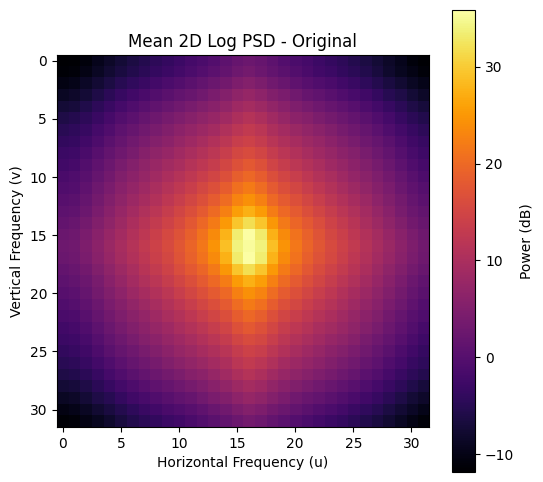

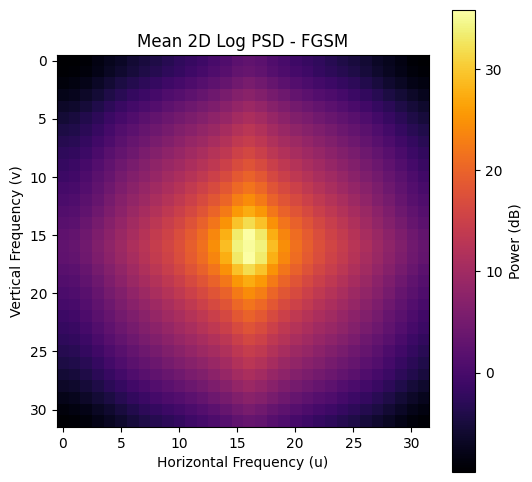

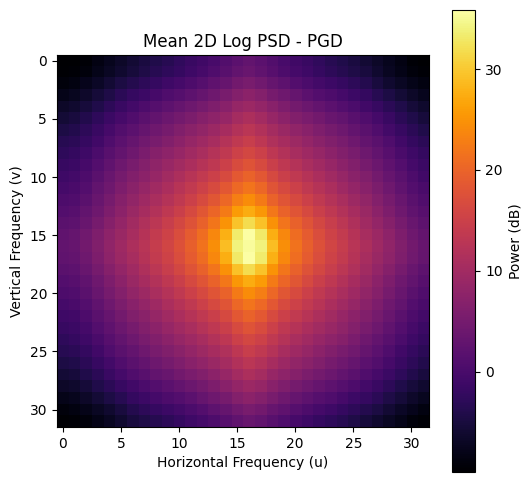

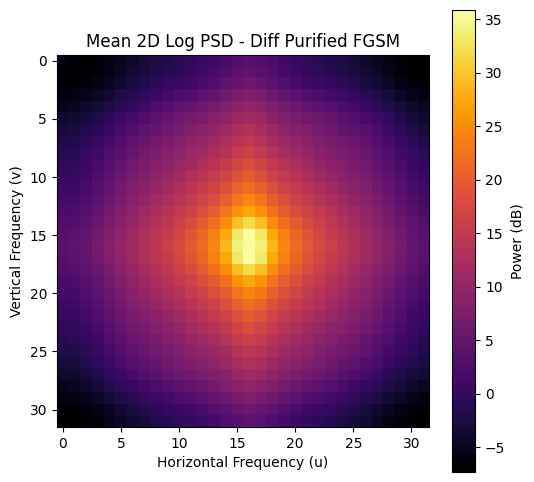

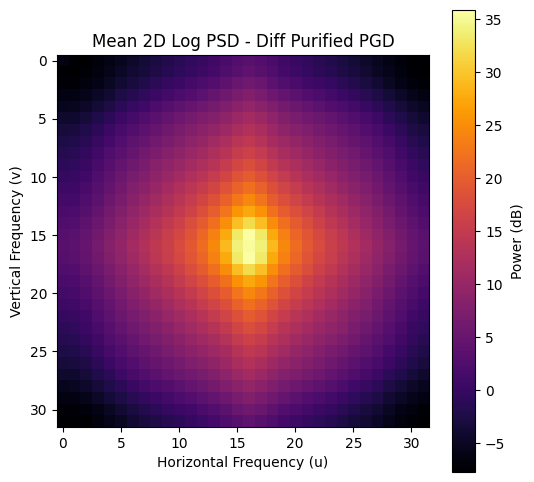

In [30]:
# Extract the underlying image tensors for plotting
original_images, _ = original_loader.dataset.tensors
fgsm_images, _ = fgsm_loader.dataset.tensors
pgd_images, _ = pgd_loader.dataset.tensors
diff_purified_fgsm_images, _ = diff_purified_fgsm_loader.dataset.tensors
diff_purified_pgd_images, _ = diff_purified_pgd_loader.dataset.tensors

# Instantiate the analyzer once
analyzer = SpectralAnalyzer(spatial_shape=(32, 32), device=device)

# Plot 2D heatmaps (automatically averages the whole batch)
analyzer.plot_2d(original_images, title="Mean 2D Log PSD - Original")
analyzer.plot_2d(fgsm_images, title="Mean 2D Log PSD - FGSM")
analyzer.plot_2d(pgd_images, title="Mean 2D Log PSD - PGD")
analyzer.plot_2d(diff_purified_fgsm_images, title="Mean 2D Log PSD - Diff Purified FGSM")
analyzer.plot_2d(diff_purified_pgd_images, title="Mean 2D Log PSD - Diff Purified PGD")

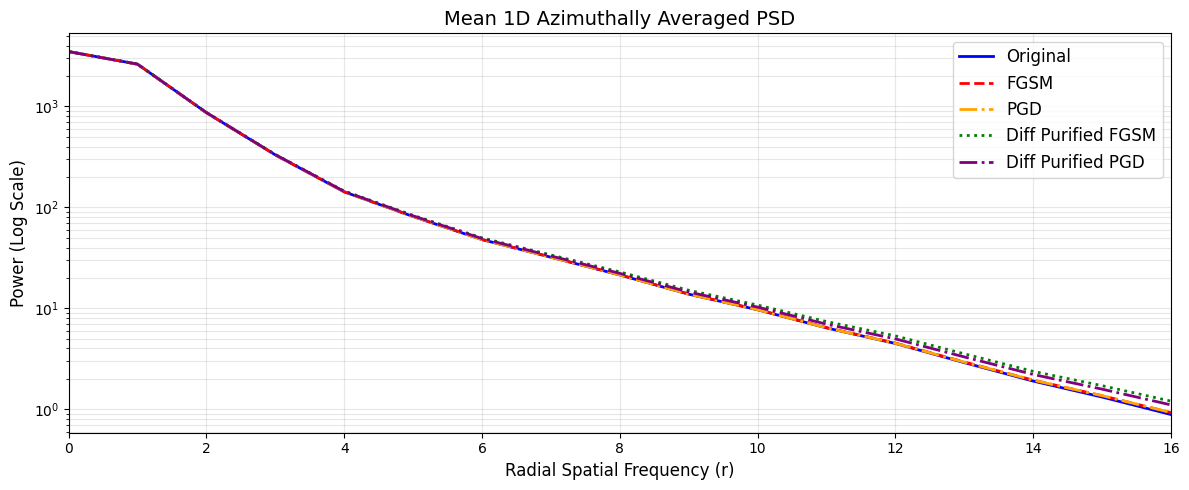

/Users/austinb.dev.bc/Projects/gap/src/gap/spectral.py:219: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0, top=100)


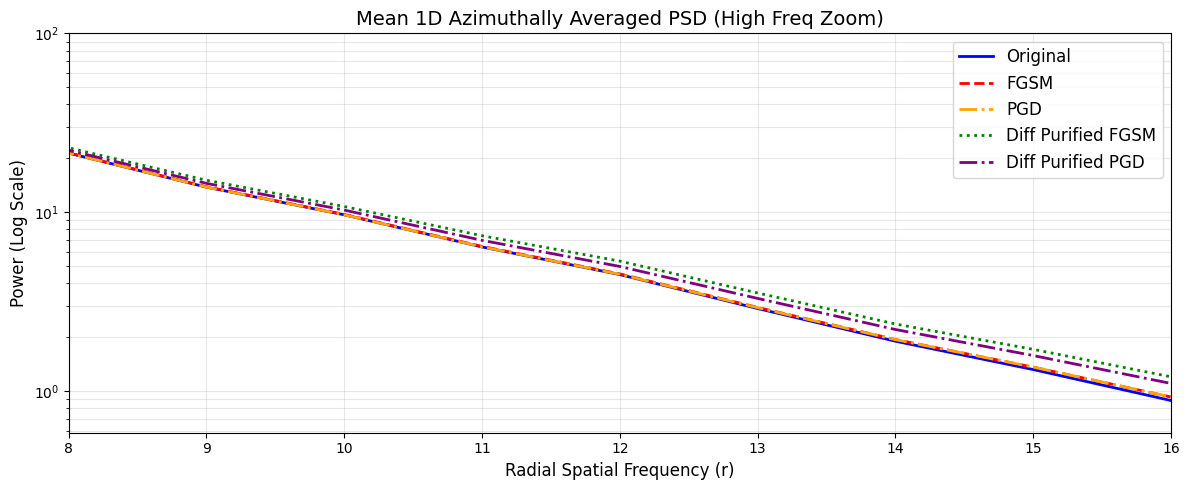

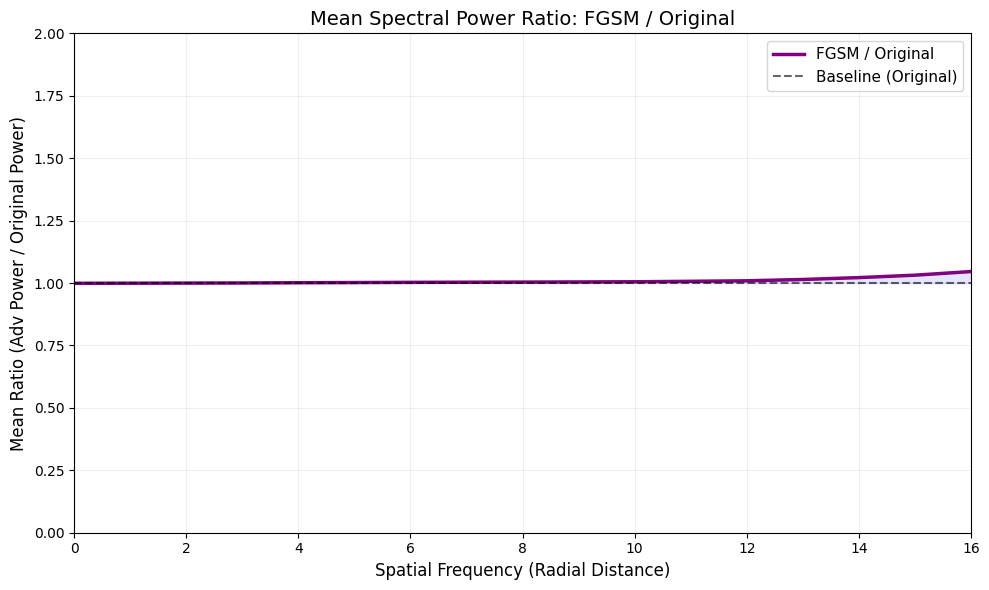

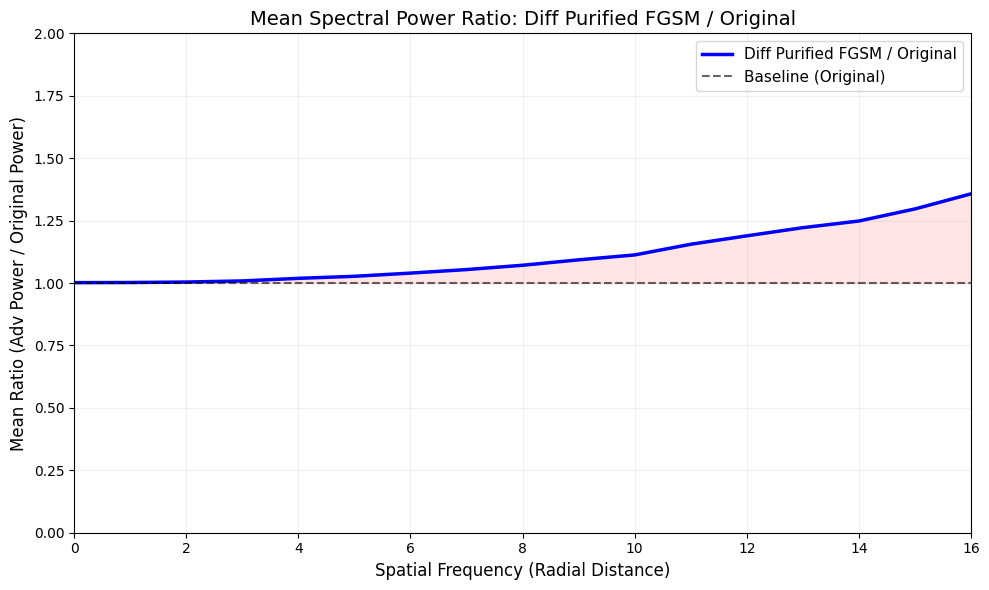

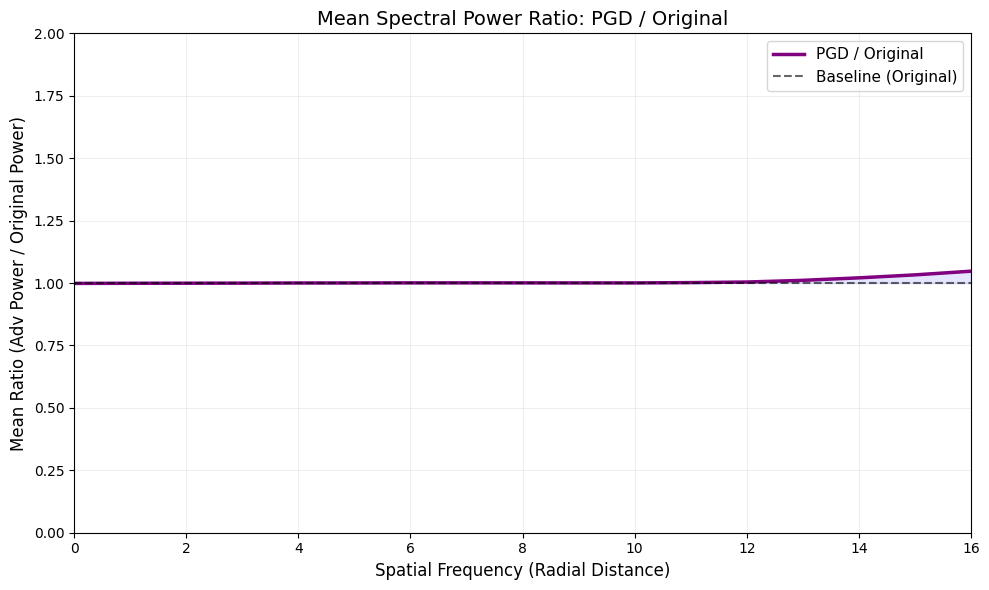

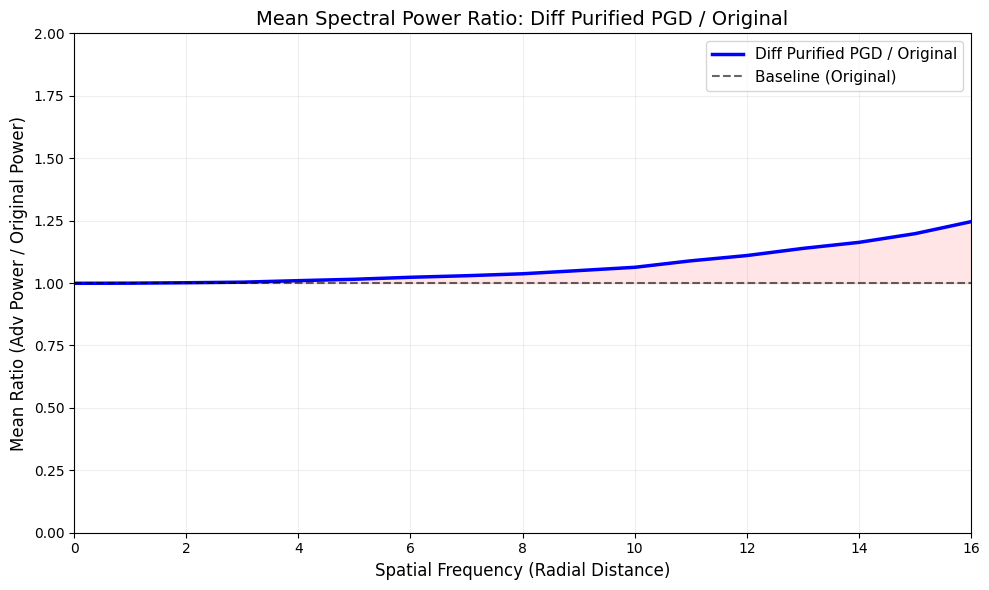

In [31]:
# Compare their 1D profiles on the same plot
image_label_dict = {"Original": original_images, "FGSM": fgsm_images, "PGD": pgd_images, "Diff Purified FGSM": diff_purified_fgsm_images, "Diff Purified PGD": diff_purified_pgd_images}
analyzer.plot_1d(image_label_dict)

# Compare their 1D profiles on the same plot
analyzer.plot_1d(
    image_label_dict, zoom_high_freq=True
)

analyzer.plot_1d_ratio(original_images, fgsm_images, diff_purified_fgsm_images, label_21="FGSM / Original", label_31="Diff Purified FGSM / Original")
analyzer.plot_1d_ratio(original_images, pgd_images, diff_purified_pgd_images, label_21="PGD / Original", label_31="Diff Purified PGD / Original")

Dataset    | Mean Low-Freq Power (dB) | Mean High-Freq Power (dB)
-------------------------------------------------------
Original   | 24.5933              | 6.3524              
FGSM       | 24.5973              | 6.4202              
PGD        | 24.5922              | 6.4088              
Diff Purified FGSM | 24.6762              | 7.1096              
Diff Purified PGD | 24.6361              | 6.8430              


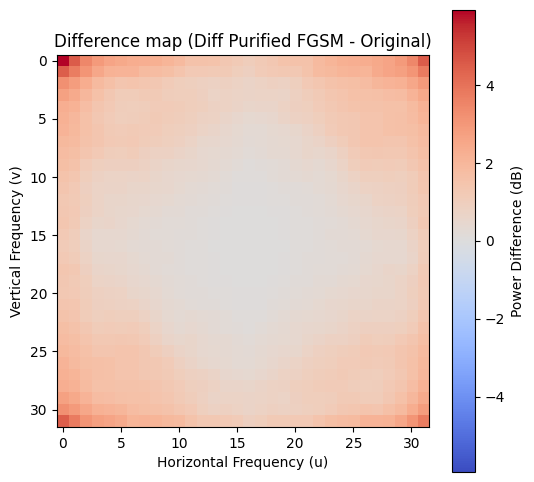

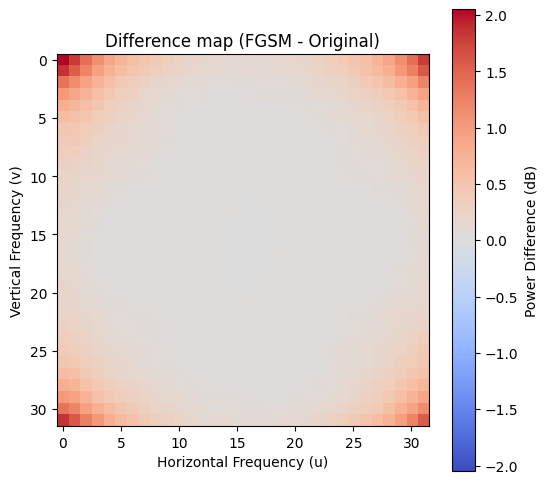

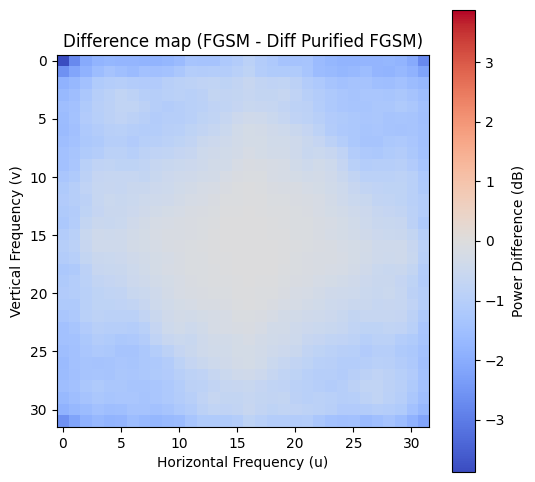

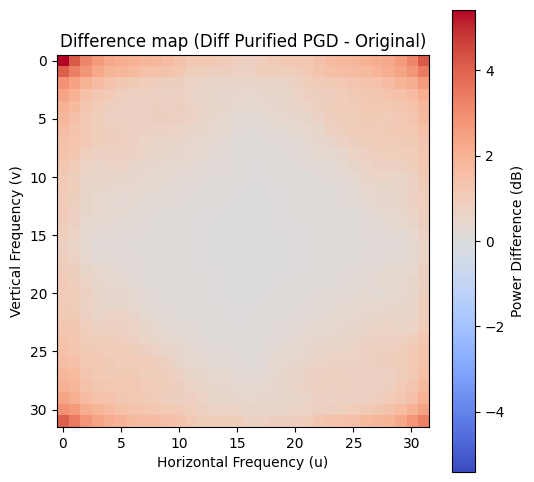

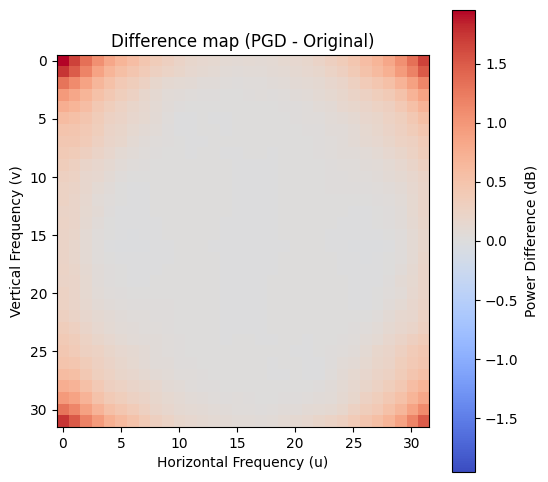

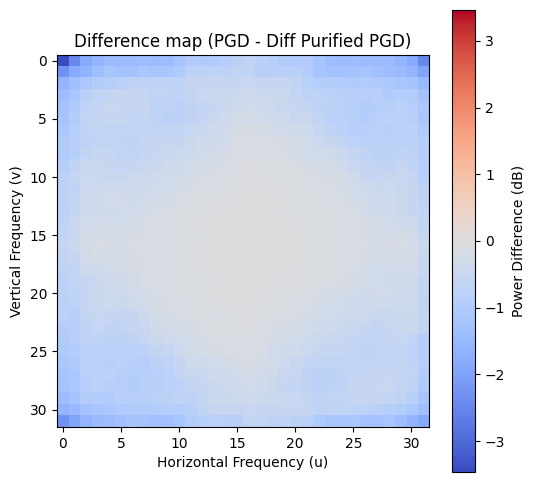

In [32]:
analyzer.print_spectral_stats(image_label_dict)

analyzer.plot_2d_difference(
    images_1=original_images,
    images_3=fgsm_images,
    images_2=diff_purified_fgsm_images,
    title_31="Difference map (FGSM - Original)",
    title_21="Difference map (Diff Purified FGSM - Original)",
    title_32="Difference map (FGSM - Diff Purified FGSM)"
)

analyzer.plot_2d_difference(
    images_1=original_images,
    images_3=pgd_images,
    images_2=diff_purified_pgd_images,
    title_31="Difference map (PGD - Original)",
    title_21="Difference map (Diff Purified PGD - Original)",
    title_32="Difference map (PGD - Diff Purified PGD)"
)


In [37]:
def prep_image(tensor_img):
    """
    Formats a single image tensor for Matplotlib.
    Since no normalization was used, we only need to clamp and permute.
    """
    img = tensor_img.clone().detach().cpu()
    
    # Clamp to strictly [0, 1] to avoid Matplotlib display warnings
    img = torch.clamp(img, 0.0, 1.0)
    
    # Permute from (C, H, W) to (H, W, C) for Matplotlib
    return img.permute(1, 2, 0).numpy()


def comparison_grid(idx=None):
    # 1. Extract the raw image tensors
    clean_imgs, _ = original_loader.dataset.tensors
    fgsm_imgs, _ = fgsm_loader.dataset.tensors
    pgd_imgs, _ = pgd_loader.dataset.tensors
    # diff_purified_fgsm_images and diff_purified_pgd_images should be loaded/available

    # 2. Pick a random index
    if idx is None:
        idx = random.randint(0, len(clean_imgs) - np.random.randint(0, len(clean_imgs)-1))

    # 3. Prepare all 5 images for plotting (No mean/std needed!)
    img_orig = prep_image(clean_imgs[idx])
    img_fgsm = prep_image(fgsm_imgs[idx])
    img_pgd = prep_image(pgd_imgs[idx])
    img_cln_fgsm = prep_image(diff_purified_fgsm_images[idx])
    img_cln_pgd = prep_image(diff_purified_pgd_images[idx])

    # 4. Plot them side-by-side
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    images_to_plot = [img_orig, img_fgsm, img_pgd, img_cln_fgsm, img_cln_pgd]
    titles = [
        "Original", 
        "FGSM Adversarial", 
        "PGD Adversarial", 
        "Diff Purified FGSM", 
        "Diff Purified PGD"
    ]

    for ax, img, title in zip(axes, images_to_plot, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


Generating visual comparison grid...
[6479  537 5482 4741 6992]


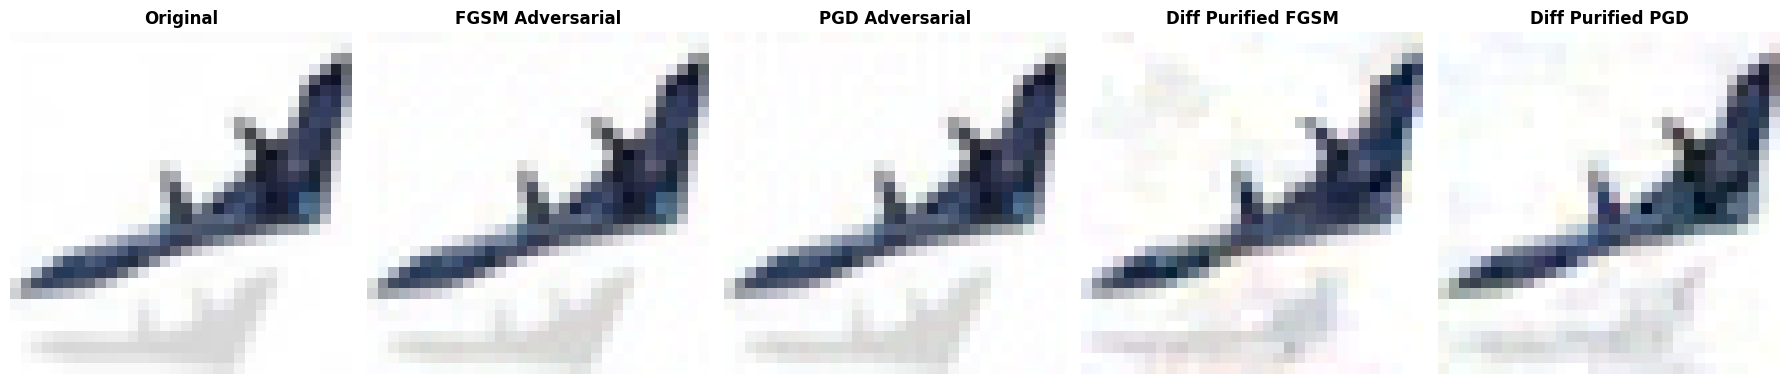

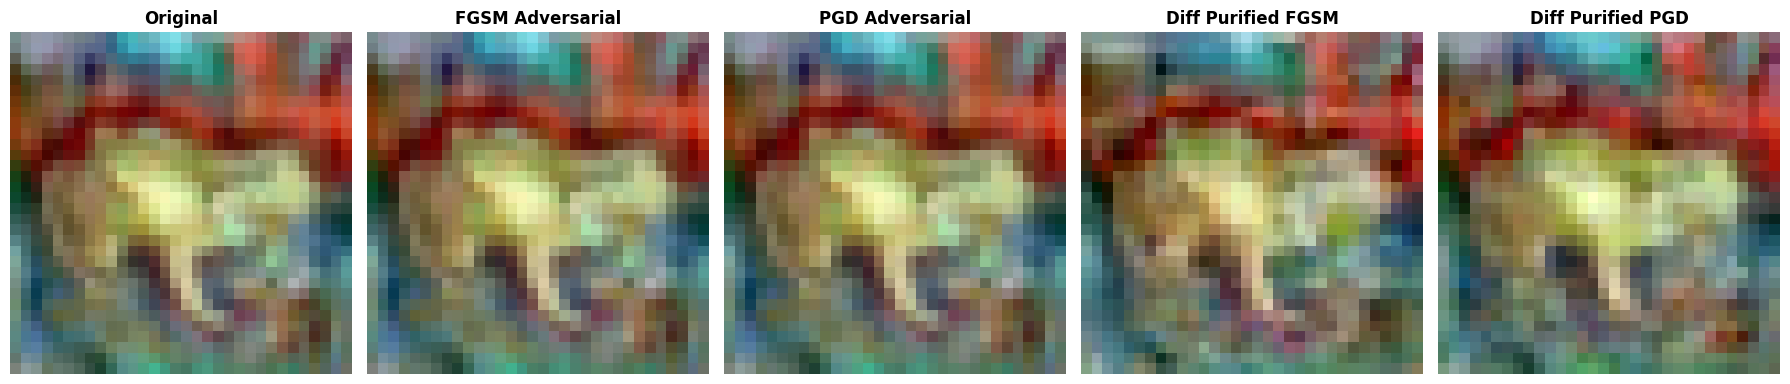

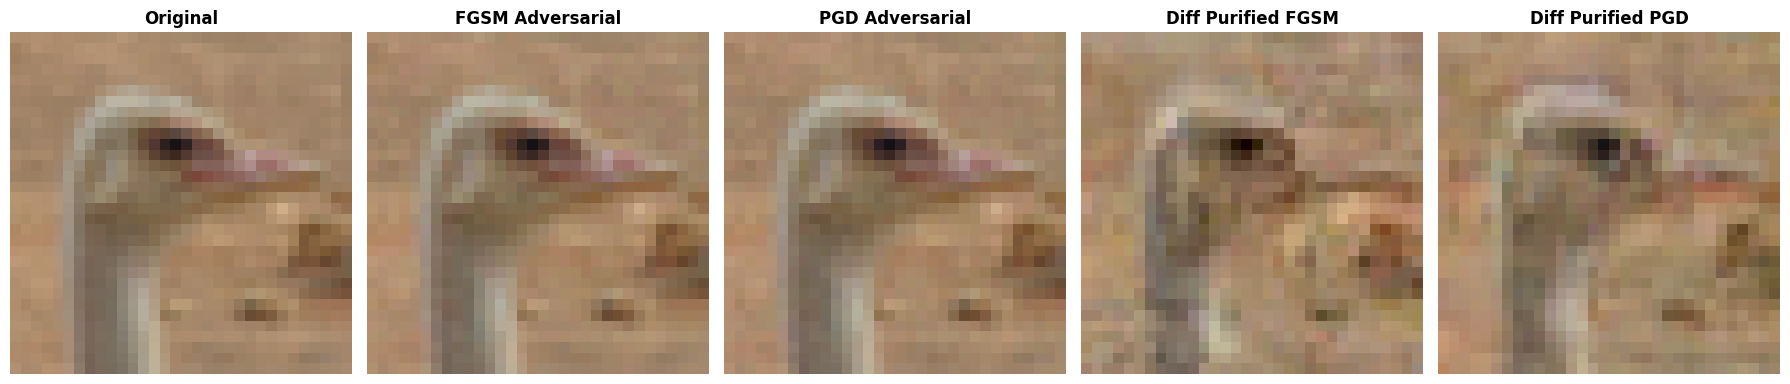

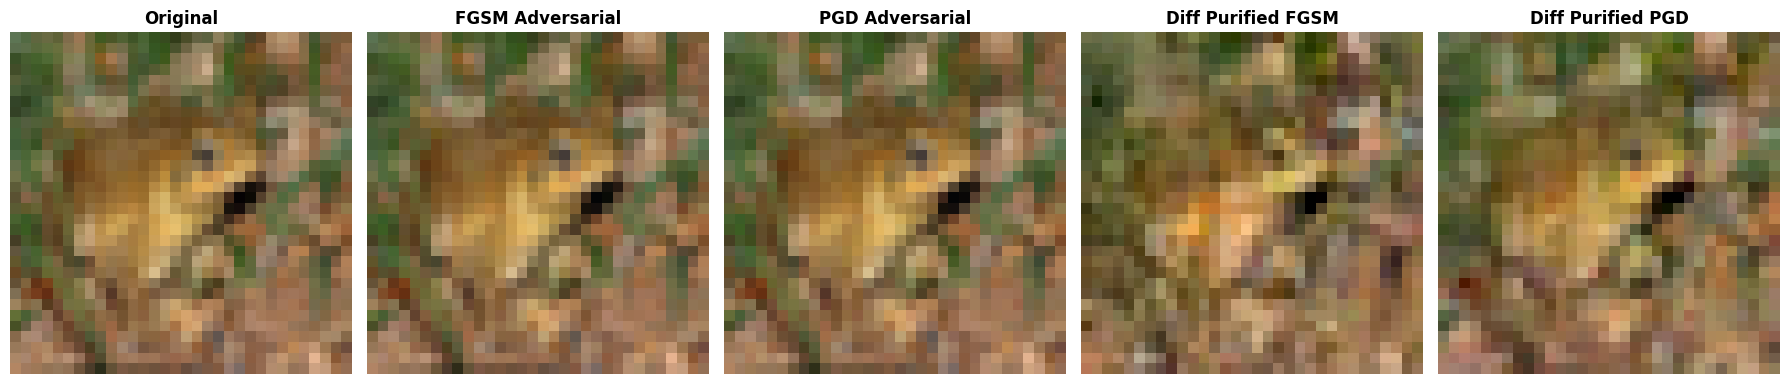

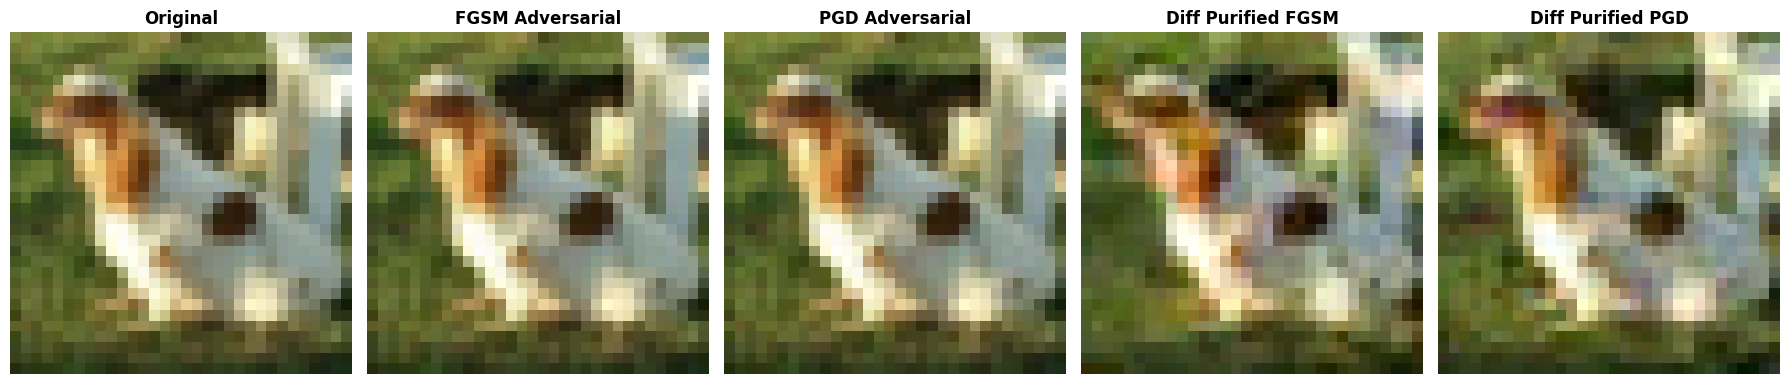

In [43]:
print("\nGenerating visual comparison grid...")

idxs = np.random.randint(0, len(original_loader.dataset.tensors[0]) - 1, 5)
print(idxs)
for idx in idxs:
    comparison_grid(idx)